In [11]:
import pandas as pd
# Login using e.g. `huggingface-cli login` to access this dataset
df = pd.read_parquet("hf://datasets/ahmed-masry/ChartQAPro/data")

In [12]:
df.head()

,Question,Answer,Question Type,image,Year,Paragraph
0,[estimate the year in which wind capacity firs...,[2037-38],Factoid,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,[NO],
1,[determine the airline with the highest increa...,[United Airlines],Factoid,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,[NO],
2,[how many times the retail sales growth went b...,[3],Factoid,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,[NO],
3,[which year (from the x-axis) had the highest ...,[2010],Factoid,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,[Yes],
4,[what is the absolute difference between the p...,[6],Factoid,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,[NO],


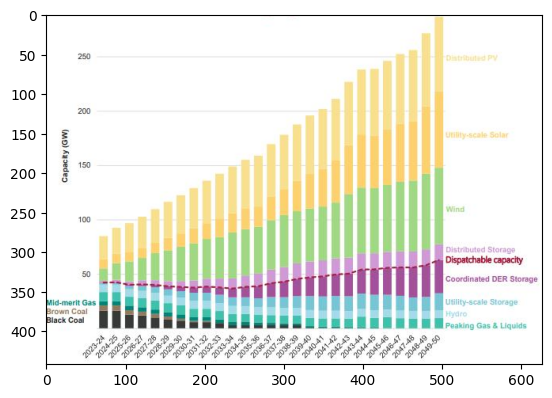

In [3]:
# Help me visulalize the image in the dataframe
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
image_data = df.iloc[0]['image']
image = Image.open(BytesIO(image_data))
plt.imshow(image)

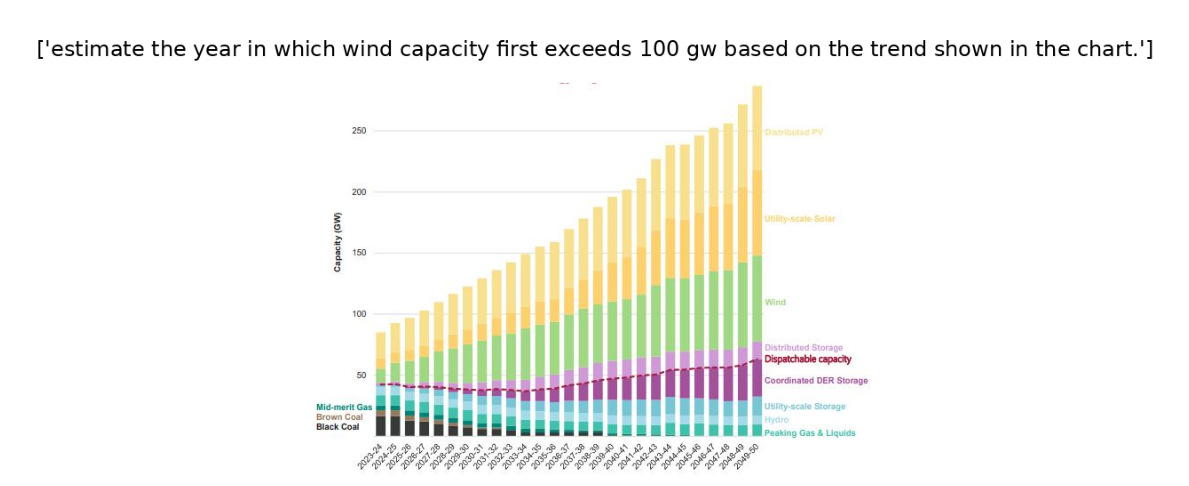

In [4]:
# Now can u help me browse the question, convert that to an image and merge in the chart image and question image vertically?
from PIL import ImageDraw, ImageFont
question = str(df.iloc[0]['Question'])
# Create an image for the question with larger font
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 24)
except:
    font = ImageFont.load_default(size=20)
    
# Calculate size of the text using a temporary draw object
temp_image = Image.new('RGB', (1, 1))
temp_draw = ImageDraw.Draw(temp_image)
bbox = temp_draw.textbbox((0, 0), question, font=font)
text_width = bbox[2] - bbox[0]
text_height = bbox[3] - bbox[1]

# Create a new image with white background and padding
padding = 30
question_image = Image.new('RGB', (text_width + 2*padding, text_height + 2*padding), color=(255, 255, 255))
d = ImageDraw.Draw(question_image)
d.text((padding, padding), question, font=font, fill=(0, 0, 0))

# Combine the question image and chart image vertically
chart_image = image
total_height = question_image.height + chart_image.height
max_width = max(question_image.width, chart_image.width)
combined_image = Image.new('RGB', (max_width, total_height), (255, 255, 255))
combined_image.paste(question_image, ((max_width - question_image.width) // 2, 0))
combined_image.paste(chart_image, ((max_width - chart_image.width) // 2, question_image.height))

plt.figure(figsize=(12, 10))
plt.imshow(combined_image)
plt.axis('off')
plt.tight_layout()
plt.show()


Avg sentence length: 19.123716632443532
Avg lexical diversity: 0.9051169252058547


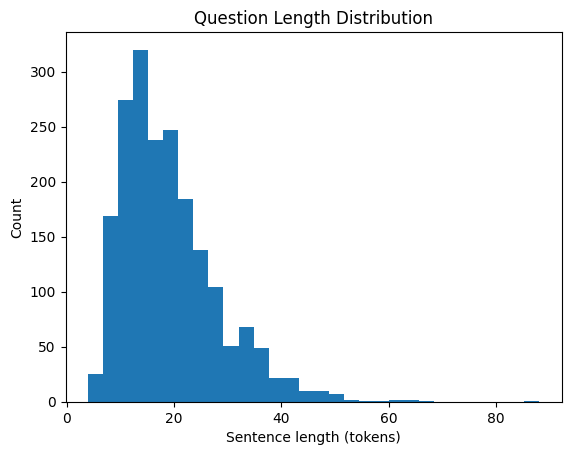

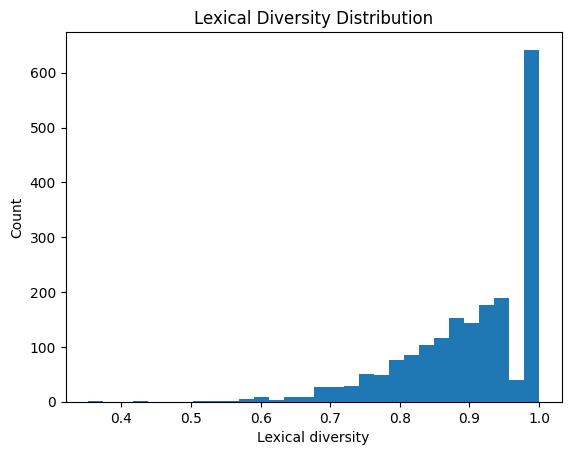

In [8]:
"""
Using a small sample of the data (e.g. validation splits), generate statistics and plots for three relevant
properties of the data.
1. Lexical diversity, sentence length, ...
2. Average number of objects detected per image
3. Degrees of freedom, number of articulated objects, ...
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

df = pd.read_parquet("hf://datasets/ahmed-masry/ChartQAPro/data/test-00000-of-00001.parquet")

# unwrap list-like fields (they're stored as lists)
df["question"] = df["Question"].apply(lambda x: x[0])
df["answer"] = df["Answer"].apply(lambda x: x[0])
df["year_required"] = df["Year"].apply(lambda x: x[0])

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

df["tokens"] = df["question"].apply(tokenize)
df["num_tokens"] = df["tokens"].apply(len)

# lexical diversity = unique tokens / total tokens
df["lexical_diversity"] = df["tokens"].apply(
    lambda toks: len(set(toks)) / len(toks) if len(toks) > 0 else 0
)

print("Avg sentence length:", df["num_tokens"].mean())
print("Avg lexical diversity:", df["lexical_diversity"].mean())

plt.hist(df["num_tokens"], bins=30)
plt.xlabel("Sentence length (tokens)")
plt.ylabel("Count")
plt.title("Question Length Distribution")
plt.show()

plt.hist(df["lexical_diversity"], bins=30)
plt.xlabel("Lexical diversity")
plt.ylabel("Count")
plt.title("Lexical Diversity Distribution")
plt.show()

/home/mhira/miniconda3/envs/ezswitch/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mhira/miniconda3/envs/ezswitch/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /home/mhira/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 96.7MB/s] 


Avg objects per image: 0.44


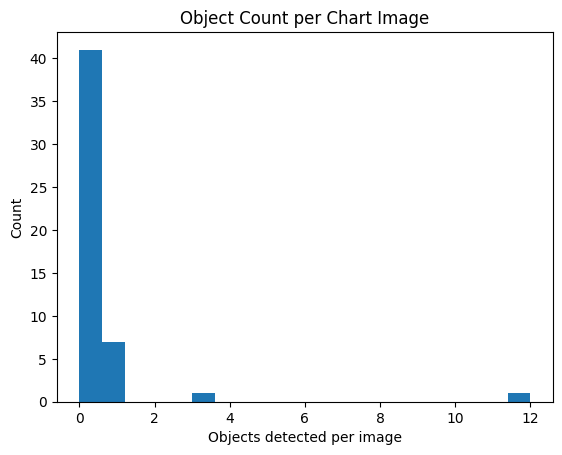

In [6]:
from PIL import Image
import io

def decode_image(img_bytes):
    return Image.open(io.BytesIO(img_bytes)).convert("RGB")

df["pil_image"] = df["image"].apply(decode_image)

import torch
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn

device = "cuda" if torch.cuda.is_available() else "cpu"
model = fasterrcnn_resnet50_fpn(pretrained=True).to(device)
model.eval()

transform = T.Compose([T.ToTensor()])

def count_objects(image, score_thresh=0.5):
    with torch.no_grad():
        img_t = transform(image).to(device)
        output = model([img_t])[0]
    scores = output["scores"].cpu().numpy()
    return int((scores > score_thresh).sum())

sample_df = df.sample(n=50, random_state=42)
sample_df["num_objects"] = sample_df["pil_image"].apply(count_objects)

print("Avg objects per image:", sample_df["num_objects"].mean())

plt.hist(sample_df["num_objects"], bins=20)
plt.xlabel("Objects detected per image")
plt.ylabel("Count")
plt.title("Object Count per Chart Image")
plt.show()



Avg numeric refs: 1.6632443531827514
Avg comparative ops: 0.42299794661190965
Question type distribution:
Question Type
Factoid           1081
Conversational     311
Fact Checking      244
Multi Choice       214
Hypothetical        98
Name: count, dtype: int64

Requires year reasoning:
year_required
NO     1885
Yes      51
YES      12
Name: count, dtype: int64


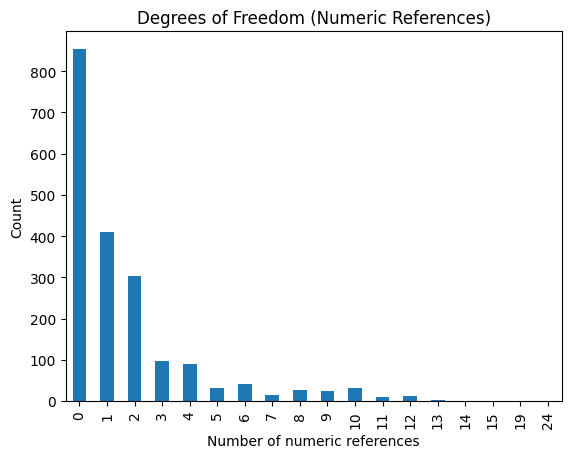

In [7]:
def count_numeric_refs(text):
    return len(re.findall(r"\d+", text))

def count_comparatives(text):
    comps = ["increase", "decrease", "difference", "highest", "lowest", "compare"]
    return sum(word in text.lower() for word in comps)

df["numeric_refs"] = df["question"].apply(count_numeric_refs)
df["comparatives"] = df["question"].apply(count_comparatives)
print("Avg numeric refs:", df["numeric_refs"].mean())
print("Avg comparative ops:", df["comparatives"].mean())
complexity = (
    df["Question Type"].value_counts(normalize=True),
    df["year_required"].value_counts(normalize=True)
)

print("Question type distribution:")
print(df["Question Type"].value_counts())

print("\nRequires year reasoning:")
print(df["year_required"].value_counts())
df["numeric_refs"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of numeric references")
plt.ylabel("Count")
plt.title("Degrees of Freedom (Numeric References)")
plt.show()


In [10]:
print("Question type distribution:")
print(df["Question Type"].unique())

Question type distribution:
['Factoid' 'Conversational' 'Hypothetical' 'Fact Checking' 'Multi Choice']


In [21]:
df["is_unanswerable"] = df["Answer"].apply(lambda x: x[0] == "Unanswerable")
df.groupby("Question Type")["is_unanswerable"].sum()


Question Type
Conversational      0
Fact Checking      42
Factoid           262
Hypothetical        2
Multi Choice       48
Name: is_unanswerable, dtype: int64

In [22]:
df["Answer"]

0               [2037-38]
1       [United Airlines]
2                     [3]
3                  [2010]
4                     [6]
              ...        
1943       [Unanswerable]
1944       [Unanswerable]
1945                [Yes]
1946           [04:00 AM]
1947               [2016]
Name: Answer, Length: 1948, dtype: object